# Median mass accretion histories

Median $M_{\rm vir}(z)$ across the 1000 trees in each of the 8 `N1000` host-mass bins (`data/zhao/N1000/median_MAH/*.npz`).

In [1]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib as mpl
import warnings; warnings.simplefilter('ignore')
import glob
import os


In [2]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches


In [3]:
# median MAH files built from the 8 x 1000-tree N1000 sample
# (data/zhao/N1000/median_MAH/*.npz -- one file per host mass bin,
# each holding the shared z axis and the per-timestep median of the
# main-progenitor mass across that bin's 1000 trees)
mah_dir = "../../data/zhao/N1000/median_MAH/"
mah_files = sorted(glob.glob(mah_dir + "*_median_MAH.npz"))

logMvir_bins = np.array([float(os.path.basename(f).split("_")[0]) for f in mah_files])
mvir_label = [f"$\\mathbb{{S}}_{{{m:.1f}}}$" for m in logMvir_bins]

z = np.load(mah_files[0])["z"]  # shared time axis, identical across files
M = np.stack([np.load(f)["M"] for f in mah_files])  # shape (n_bins, n_time)

print(f"loaded {len(mah_files)} mass bins: {logMvir_bins}")
print(f"time axis: {len(z)} steps, z = {z[0]:.2f} -> {z[-1]:.2f}")


loaded 8 mass bins: [12.6 12.8 13.  13.2 13.4 13.6 13.8 14. ]
time axis: 354 steps, z = 0.00 -> 20.06


## Absolute and normalized growth vs. redshift

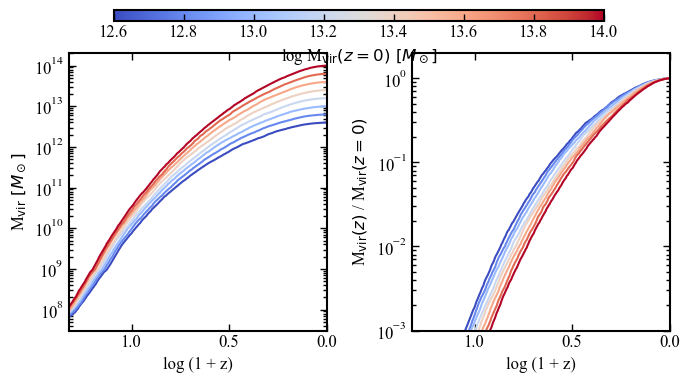

In [4]:
# --- colormap over host mass at z=0 ---
norm = mpl.colors.Normalize(vmin=logMvir_bins.min(), vmax=logMvir_bins.max())
cmap = mpl.cm.coolwarm
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

xvals = np.log10(1 + z)

fig, axes = plt.subplots(1, 2, figsize=(double_textwidth, single_textwidth), sharex=True)

for i, logM0 in enumerate(logMvir_bins):
    color = cmap(norm(logM0))
    axes[0].plot(xvals, M[i], color=color, lw=1.5)
    axes[1].plot(xvals, M[i] / M[i, 0], color=color, lw=1.5)

axes[0].set_yscale("log")
axes[0].set_xlim(xvals.max(), 0)
axes[0].set_ylabel(r"M$_{\rm vir}\ [M_\odot]$")

axes[1].set_yscale("log")
axes[1].set_ylim(1e-3, 2)
axes[1].set_ylabel(r"M$_{\rm vir}(z)$ / M$_{\rm vir}(z=0)$")

for ax in axes:
    ax.set_xlabel("log (1 + z)")

plt.subplots_adjust(top=0.98)
cbar_ax = fig.add_axes([0.17, 1.05, 0.7, 0.03])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label(r"log M$_{\rm vir}(z=0)\ [M_\odot]$", loc="center")

plt.tight_layout()
# plt.savefig("../../figures/median_MAH_vs_z.pdf", bbox_inches="tight")  # not auto-saving to disk -- left inline only
plt.show()


## Growth vs. cosmic time

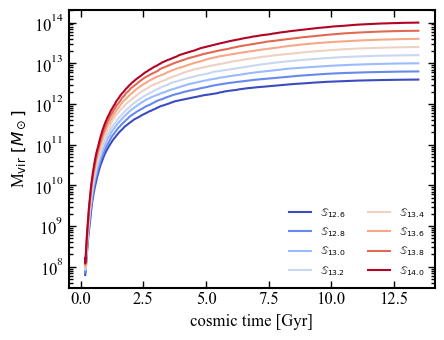

In [5]:
# same medians, but against cosmic time (Gyr since the Big Bang) instead of z
from scipy.interpolate import interp1d

h, Om, OL = 0.7, 0.3, 0.7
def cosmic_time(zarr, h=h, Om=Om, OL=OL):
    fac = OL / (1. + zarr)**3
    return (9.778 / h) * 2. / (3. * np.sqrt(OL)) * np.log((np.sqrt(fac) + np.sqrt(fac + Om)) / np.sqrt(Om))

t_gyr = cosmic_time(z)

fig, ax = plt.subplots(1, 1, figsize=(single_textwidth * 1.3, single_textwidth))

for i, logM0 in enumerate(logMvir_bins):
    color = cmap(norm(logM0))
    ax.plot(t_gyr, M[i], color=color, lw=1.5, label=mvir_label[i])

ax.set_yscale("log")
ax.set_xlabel("cosmic time [Gyr]")
ax.set_ylabel(r"M$_{\rm vir}\ [M_\odot]$")
ax.legend(fontsize=8, ncol=2, frameon=False, loc="lower right")

plt.tight_layout()
# plt.savefig("../../figures/median_MAH_vs_t.pdf", bbox_inches="tight")  # not auto-saving to disk -- left inline only
plt.show()


## $M_{\rm unique} / M_{\rm mean}$ ratio diagnostic

Per-timestep ratio of each of the 1000 individual trees' MAH to the bin's mean MAH (`data/zhao/N1000/ratio_MAH/*.npz`, shape `(1000, 354)` per bin). This is the raw quantity `epsilon(z)` will be built from -- evaluated at each subhalo's own accretion redshift, scaling its initial radial velocity by how fast/slow its host was accreting relative to the ensemble at that epoch. Shown here unsmoothed, to see the noise floor before any fitting.

In [6]:
# per-subhalo-initialization diagnostic: ratio of each unique tree's MAH
# to the bin's mean MAH, at every timestep -- this is the quantity
# epsilon(z) will be built from (evaluated at each subhalo's own
# accretion redshift, per the epsilon_orbit_init.py convention).
# data/zhao/N1000/ratio_MAH/*.npz -- one file per mass bin, each holding
# ratio: (1000, 354) = MAH[tree, time] / mean_MAH[time], and the shared z.
ratio_dir = "../../data/zhao/N1000/ratio_MAH/"
ratio_files = sorted(glob.glob(ratio_dir + "*_ratio_MAH.npz"))

z_ratio = np.load(ratio_files[0])["z"]
assert np.allclose(z_ratio, z)  # shares the same time axis as the MAHs above

print(f"{'bin':>6} {'min':>10} {'p5':>10} {'p16':>10} {'p84':>10} {'p95':>10} {'max':>10}")
ratio_stats = {}
for logM0, rf in zip(logMvir_bins, ratio_files):
    ratio = np.load(rf)["ratio"]  # (1000, 354)
    p5, p16, p50, p84, p95 = np.nanpercentile(ratio, [5, 16, 50, 84, 95], axis=0)
    finite = ratio[np.isfinite(ratio)]
    ratio_stats[logM0] = dict(ratio=ratio, p5=p5, p16=p16, p50=p50, p84=p84, p95=p95)
    print(f"{logM0:6.1f} {finite.min():10.3f} {p5.min():10.3f} {p16.min():10.3f} "
          f"{p84.max():10.3f} {p95.max():10.3f} {finite.max():10.3f}")


   bin        min         p5        p16        p84        p95        max
  12.6      0.018      0.128      0.245      1.810      3.400     13.099
  12.8      0.018      0.120      0.231      1.790      3.341     11.661
  13.0      0.028      0.107      0.213      1.862      3.384     10.100
  13.2      0.026      0.120      0.231      1.777      3.488     17.989
  13.4      0.012      0.113      0.221      1.858      3.510     14.207
  13.6      0.013      0.115      0.224      1.816      3.127     11.207
  13.8      0.020      0.120      0.230      1.765      3.269     13.712
  14.0      0.017      0.109      0.223      1.816      3.131     17.069


In [7]:
# two characteristic timescales per mass bin, to compare against the
# ratio's spread:
#  - x_cross : where the ensemble median (M_unique/M_mean) crosses 1,
#              excluding the trivial z=0 endpoint -- i.e. the point past
#              which the "typical" tree's growth catches up to the mean
#  - x_z50   : log10(1 + <z50>), each tree's own formation redshift
#              (jsm convention: nearest point to half its own z=0 mass),
#              averaged across the 1000 trees in that bin
mean_dir = "../../data/zhao/N1000/mean_MAH/"

def find_nearest1(array, value):
    idx, val = min(enumerate(array), key=lambda x: abs(x[1] - value) if np.isfinite(x[1]) else np.inf)
    return idx

for logM0 in logMvir_bins:
    s = ratio_stats[logM0]
    p50 = s["p50"]
    M_mean = np.load(mean_dir + f"{logM0:.1f}_files_mean_MAH.npz")["M"]

    # interior crossing of the median with ratio = 1 (skip the trivial z=0 point)
    sign = np.sign(p50[1:] - 1.0)
    sign_change = np.where(np.diff(sign) != 0)[0]
    if len(sign_change) > 0:
        j = sign_change[0] + 1
        y0, y1 = p50[j] - 1.0, p50[j + 1] - 1.0
        x0, x1 = xvals[j], xvals[j + 1]
        x_cross = x0 + (x1 - x0) * (0 - y0) / (y1 - y0) if y1 != y0 else x0
    else:
        x_cross = np.nan

    # each tree's own z50, from its reconstructed MAH (= ratio * mean)
    MAH_tree = s["ratio"] * M_mean[None, :]
    z50s = np.full(MAH_tree.shape[0], np.nan)
    for i in range(MAH_tree.shape[0]):
        row = MAH_tree[i]
        if not np.isfinite(row).any():
            continue
        z50s[i] = z[find_nearest1(row, row[0] / 2.0)]

    s["x_cross"] = x_cross
    s["x_z50"] = np.log10(1 + np.nanmean(z50s))

for logM0 in logMvir_bins:
    s = ratio_stats[logM0]
    print(f"{logM0:.1f}: median crosses 1 at log(1+z)={s['x_cross']:.3f}, "
          f"<z50> at log(1+z)={s['x_z50']:.3f}")


12.6: median crosses 1 at log(1+z)=0.314, <z50> at log(1+z)=0.306
12.8: median crosses 1 at log(1+z)=0.343, <z50> at log(1+z)=0.299
13.0: median crosses 1 at log(1+z)=0.299, <z50> at log(1+z)=0.286
13.2: median crosses 1 at log(1+z)=0.273, <z50> at log(1+z)=0.271
13.4: median crosses 1 at log(1+z)=0.269, <z50> at log(1+z)=0.259
13.6: median crosses 1 at log(1+z)=0.250, <z50> at log(1+z)=0.249
13.8: median crosses 1 at log(1+z)=0.236, <z50> at log(1+z)=0.236
14.0: median crosses 1 at log(1+z)=0.235, <z50> at log(1+z)=0.226


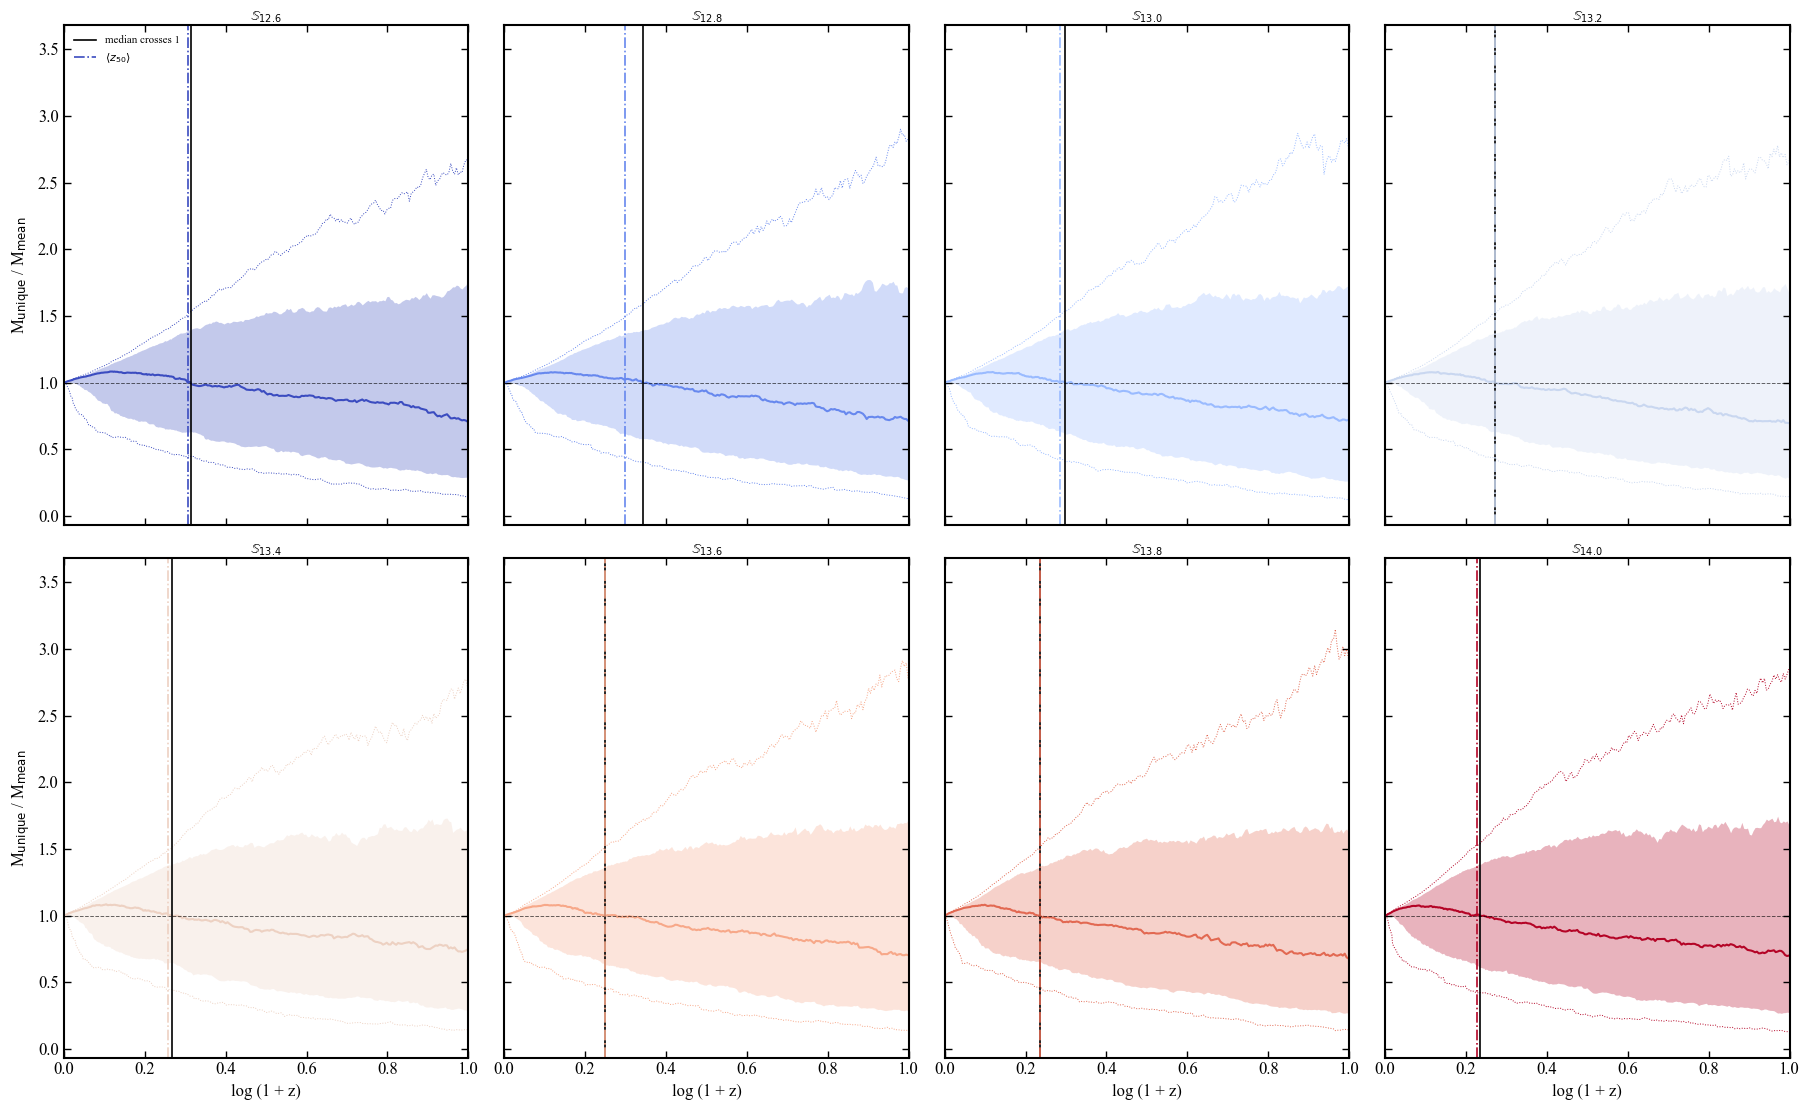

In [8]:
# range of M_unique / M_mean per mass bin: median (solid), 16-84th
# percentile (shaded), 5-95th percentile (dotted), across the 1000 trees.
# This is the noise floor epsilon(z) will inherit if built directly from
# the raw per-tree ratio, before any smoothing.
fig, axes = plt.subplots(2, 4, figsize=(double_textwidth* 2.6, double_textwidth * 1.6),
                          sharex=True, sharey=True)


axes = axes.flatten()

for i, logM0 in enumerate(logMvir_bins):
    color = cmap(norm(logM0))
    s = ratio_stats[logM0]

    ax = axes[i]
    ax.plot(xvals, s["p50"], color=color, lw=1.5)
    ax.fill_between(xvals, s["p16"], s["p84"], color=color, alpha=0.3, lw=0)
    ax.plot(xvals, s["p5"], color=color, lw=0.7, ls=":")
    ax.plot(xvals, s["p95"], color=color, lw=0.7, ls=":")
    ax.axhline(1.0, color="k", lw=0.7, ls="--", alpha=0.6)
    ax.axvline(s["x_cross"], color="k", lw=1.2, ls="-",
               label="median crosses 1" if i == 0 else None)
    ax.axvline(s["x_z50"], color=color, lw=1.2, ls="-.",
               label=r"$\langle z_{50}\rangle$" if i == 0 else None)
    ax.set_title(mvir_label[i], fontsize=10, pad=2)

for ax in axes[4:]:
    ax.set_xlabel("log (1 + z)")
    ax.set_xlim(0, 1)
for ax in [axes[0], axes[4]]:
    ax.set_ylabel(r"M$_{\rm unique}$ / M$_{\rm mean}$")

axes[0].legend(fontsize=8, frameon=False, loc="upper left")
plt.tight_layout()
# plt.savefig("../../figures/ratio_MAH_range.pdf", bbox_inches="tight")
plt.show()


## Median MAH with individual tree trajectories

Same 8 host-mass-bin panels as the ratio-range plot above, but showing actual trajectories instead of percentile statistics: each panel's median $M_{\rm vir}(z)$ (bold, from `median_MAH/*.npz`, same curve as the "Absolute and normalized growth" section) with 5 randomly chosen individual trees from that bin's 1000 (thin, reconstructed as `ratio * mean_MAH` -- same convention used for the per-tree $z_{50}$ calculation above). Sampled with a fixed seed (`rng = np.random.default_rng(42)`), independently per mass bin.

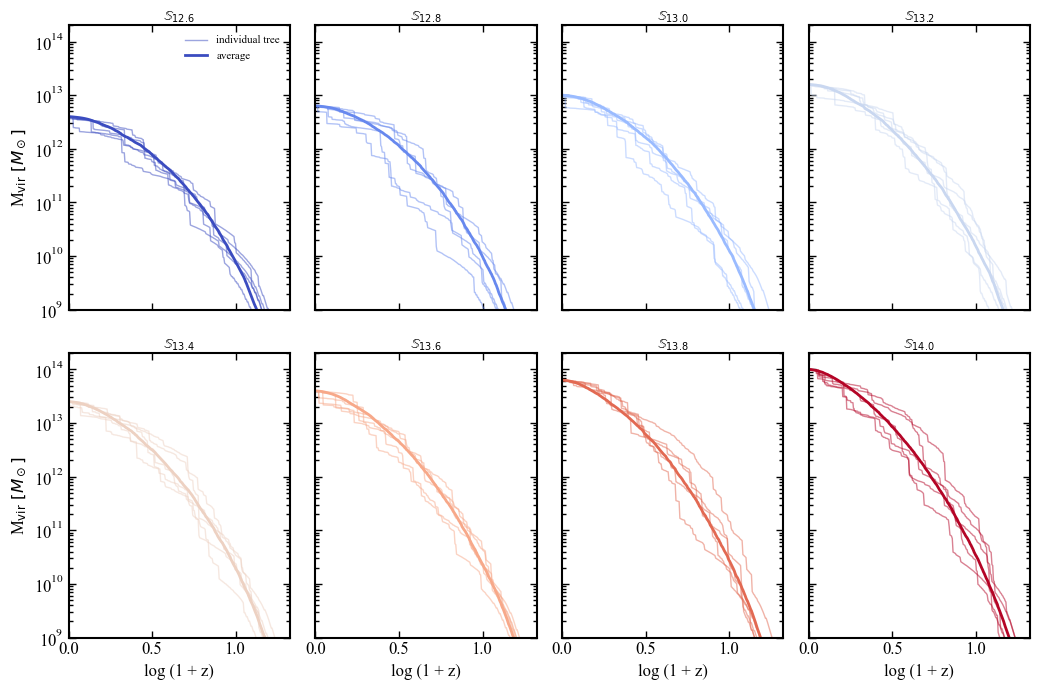

In [17]:
# median MAH per mass bin (solid, same M[i] as the "Absolute and normalized
# growth" cells above) with 5 randomly selected individual trees' own MAHs
# overplotted (thin, reconstructed as ratio * mean_MAH -- same convention
# as cell 10's per-tree z50 calculation), instead of the percentile-band
# summary in the ratio-range plot above. Same 8-panel (2x4) layout.
rng = np.random.default_rng(42)
n_show = 5

fig, axes = plt.subplots(2, 4, figsize=(double_textwidth*1.5, double_textwidth),
                          sharex=True, sharey=True)
axes = axes.flatten()

for i, logM0 in enumerate(logMvir_bins):
    color = cmap(norm(logM0))
    ratio = ratio_stats[logM0]["ratio"]
    M_mean = np.load(mean_dir + f"{logM0:.1f}_files_mean_MAH.npz")["M"]
    MAH_tree = ratio * M_mean[None, :]  # (1000, 354), each row a tree's own absolute MAH

    n_trees = MAH_tree.shape[0]
    sample_idx = rng.choice(n_trees, size=n_show, replace=False)

    ax = axes[i]
    for k, j in enumerate(sample_idx):
        ax.plot(xvals, MAH_tree[j], color=color, lw=1, alpha=0.5,
                 label="individual tree" if (i == 0 and k == 0) else None)
    ax.plot(xvals, M[i], color=color, lw=2, label="average" if i == 0 else None)
    ax.set_yscale("log")
    ax.set_xlim(0, xvals.max())
    ax.set_ylim(1e9, 2e14)
    ax.set_title(mvir_label[i], fontsize=10, pad=2)

for ax in axes[4:]:
    ax.set_xlabel("log (1 + z)")
for ax in [axes[0], axes[4]]:
    ax.set_ylabel(r"M$_{\rm vir}\ [M_\odot]$")

axes[0].legend(fontsize=8, frameon=False, loc="upper right")
plt.tight_layout()
# plt.savefig("../../figures/median_MAH_individual_trees.pdf", bbox_inches="tight")  # not auto-saving to disk -- left inline only
plt.show()